In [2]:
import polars as pl
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# ── Load signal ───────────────────────────────────────────
signal = pl.read_parquet('/home/bpinoli/sub-industry-correlation/data/signal.parquet')
clf_df = (
    signal
    .filter(
        pl.col('signal').is_not_null()
        & pl.col('specific_return').is_not_null()
    )
    .sort('date')
)

# ── Daily cross-sectional rank IC ─────────────────────────
daily_ic = (
    clf_df
    .group_by('date')
    .agg([
        pl.map_groups(
            exprs=['signal', 'specific_return'],
            function=lambda cols: pl.Series([spearmanr(cols[0].to_numpy(), cols[1].to_numpy())[0]]),
        ).alias('rank_ic'),
        pl.col('signal').count().alias('n_stocks'),
    ])
    .sort('date')
    .with_columns(pl.col('rank_ic').explode())
)

# Drop days with too few stocks or NaN IC
daily_ic = daily_ic.filter(
    pl.col('rank_ic').is_not_null()
    & pl.col('n_stocks').gt(10)
)

ic_arr = daily_ic['rank_ic'].to_numpy()
dates_arr = daily_ic['date'].to_list()

print(f"Days with valid IC: {len(ic_arr)}")
print(f"Mean daily IC:      {ic_arr.mean():.4f}")
print(f"Median daily IC:    {np.median(ic_arr):.4f}")
print(f"Std daily IC:       {ic_arr.std():.4f}")
print(f"IC > 0 fraction:    {(ic_arr > 0).mean():.3f}")
print(f"IC IR (mean/std):   {ic_arr.mean() / ic_arr.std():.4f}")

/tmp/ipykernel_2167731/403942994.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  function=lambda cols: pl.Series([spearmanr(cols[0].to_numpy(), cols[1].to_numpy())[0]]),


Days with valid IC: 5983
Mean daily IC:      -0.0009
Median daily IC:    -0.0001
Std daily IC:       0.0328
IC > 0 fraction:    0.499
IC IR (mean/std):   -0.0281


In [1]:
import polars as pl
import numpy as np
from scipy.stats import spearmanr

# Load PC scores to verify timing
pc = pl.read_parquet('/home/bpinoli/sub-industry-correlation/src/signal/naics_strats/EWMA_2_pass/full_results_naics_EWMA/pc_scores_ewma.parquet')

# Pick one cusip and check alignment
test_cusip = pc['cusip'].unique()[0]
test = pc.filter(pl.col('cusip') == test_cusip).sort('date').head(30)
print("Date | PC1 (uses data through day before) | Y (return on this day)")
print(test.select(['date', 'pc1', 'y']))

Date | PC1 (uses data through day before) | Y (return on this day)
shape: (30, 3)
┌────────────┬────────────┬────────┐
│ date       ┆ pc1        ┆ y      │
│ ---        ┆ ---        ┆ ---    │
│ date       ┆ f64        ┆ f64    │
╞════════════╪════════════╪════════╡
│ 2001-04-02 ┆ -11.822401 ┆ -3.06  │
│ 2001-04-03 ┆ -5.796214  ┆ -1.392 │
│ 2001-04-04 ┆ -4.005422  ┆ 0.278  │
│ 2001-04-05 ┆ -3.071173  ┆ 1.595  │
│ 2001-04-06 ┆ 1.608897   ┆ 0.343  │
│ …          ┆ …          ┆ …      │
│ 2001-05-08 ┆ 0.656055   ┆ 4.315  │
│ 2001-05-09 ┆ -6.146537  ┆ 1.08   │
│ 2001-05-10 ┆ 1.072511   ┆ -0.454 │
│ 2001-05-11 ┆ -2.528746  ┆ -1.111 │
│ 2001-05-14 ┆ 0.017671   ┆ 0.653  │
└────────────┴────────────┴────────┘


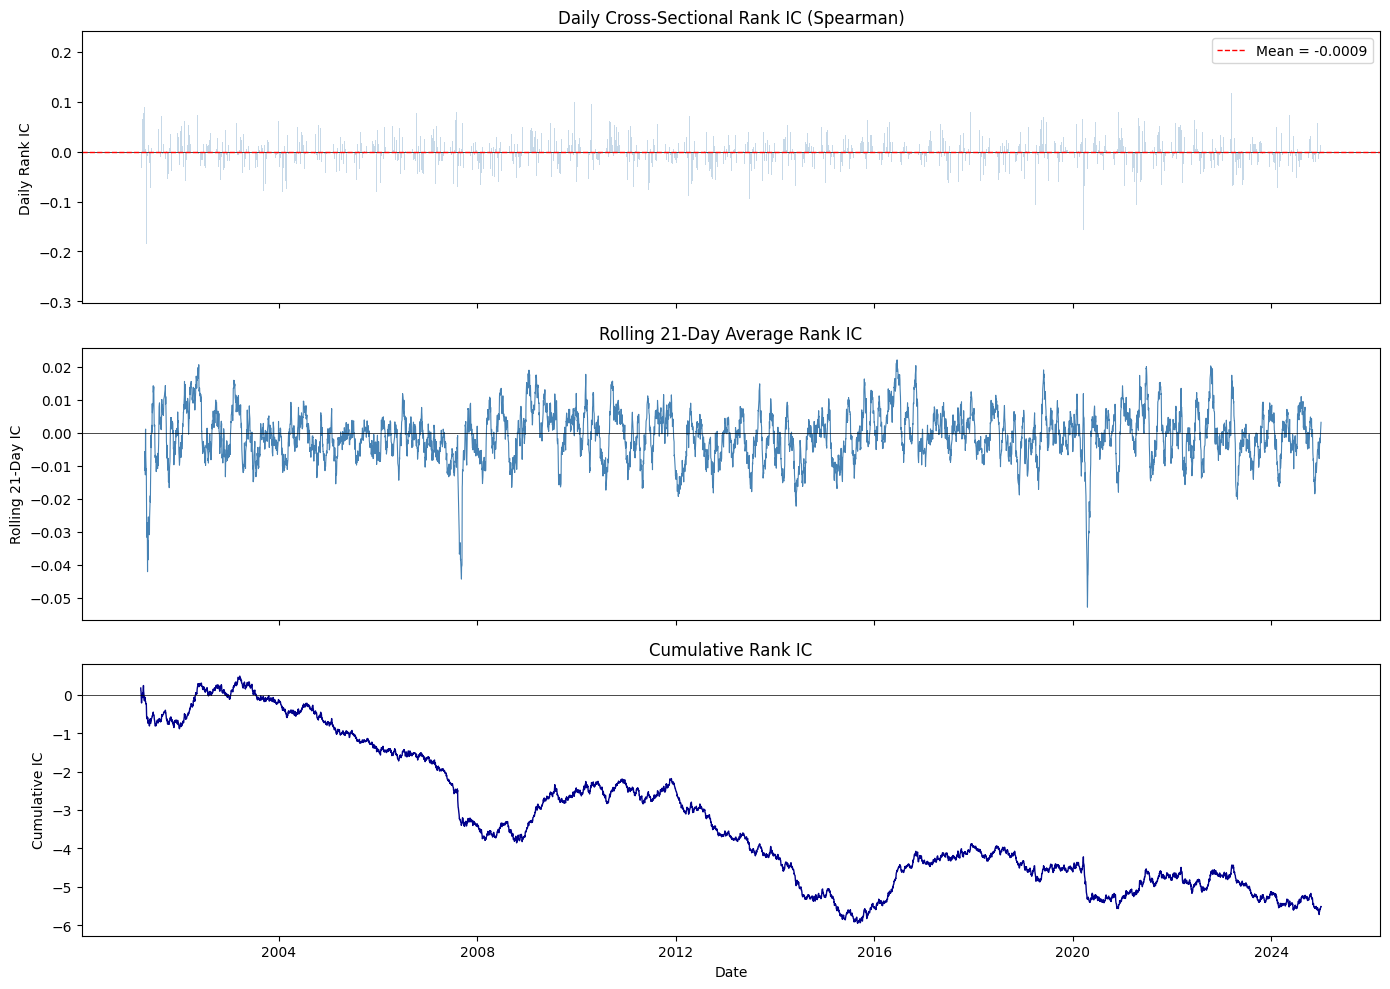

In [3]:
# ── Rolling 21-day average IC ─────────────────────────────
roll = 21
roll_ic = np.convolve(ic_arr, np.ones(roll)/roll, mode='valid')
roll_dates = dates_arr[roll-1:]

# Cumulative IC
cumul_ic = np.cumsum(ic_arr)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1: Daily IC
axes[0].bar(dates_arr, ic_arr, width=1, alpha=0.3, color='steelblue')
axes[0].axhline(0, color='black', lw=0.5)
axes[0].axhline(ic_arr.mean(), color='red', ls='--', lw=1, label=f'Mean = {ic_arr.mean():.4f}')
axes[0].set_ylabel('Daily Rank IC')
axes[0].set_title('Daily Cross-Sectional Rank IC (Spearman)')
axes[0].legend()

# Panel 2: Rolling 21-day IC
axes[1].plot(roll_dates, roll_ic, linewidth=0.8, color='steelblue')
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_ylabel('Rolling 21-Day IC')
axes[1].set_title('Rolling 21-Day Average Rank IC')

# Panel 3: Cumulative IC
axes[2].plot(dates_arr, cumul_ic, linewidth=1, color='darkblue')
axes[2].axhline(0, color='black', lw=0.5)
axes[2].set_ylabel('Cumulative IC')
axes[2].set_xlabel('Date')
axes[2].set_title('Cumulative Rank IC')

plt.tight_layout()
plt.show()

In [4]:
# ── Summary table ─────────────────────────────────────────
# Also check by year
yearly_ic = (
    daily_ic
    .with_columns(pl.col('date').dt.year().alias('year'))
    .group_by('year')
    .agg([
        pl.col('rank_ic').mean().alias('mean_ic'),
        pl.col('rank_ic').std().alias('std_ic'),
        (pl.col('rank_ic') > 0).mean().alias('pct_positive'),
        pl.col('rank_ic').count().alias('n_days'),
    ])
    .with_columns(
        (pl.col('mean_ic') / pl.col('std_ic')).alias('ic_ir')
    )
    .sort('year')
)

print("\nRank IC by Year:")
print(yearly_ic)


Rank IC by Year:
shape: (24, 6)
┌──────┬───────────┬──────────┬──────────────┬────────┬───────────┐
│ year ┆ mean_ic   ┆ std_ic   ┆ pct_positive ┆ n_days ┆ ic_ir     │
│ ---  ┆ ---       ┆ ---      ┆ ---          ┆ ---    ┆ ---       │
│ i32  ┆ f64       ┆ f64      ┆ f64          ┆ u32    ┆ f64       │
╞══════╪═══════════╪══════════╪══════════════╪════════╪═══════════╡
│ 2001 ┆ -0.004564 ┆ 0.055134 ┆ 0.458763     ┆ 194    ┆ -0.082774 │
│ 2002 ┆ 0.003199  ┆ 0.033048 ┆ 0.555556     ┆ 252    ┆ 0.096786  │
│ 2003 ┆ -0.000526 ┆ 0.032158 ┆ 0.52381      ┆ 252    ┆ -0.016369 │
│ 2004 ┆ -0.002102 ┆ 0.029877 ┆ 0.460317     ┆ 252    ┆ -0.070345 │
│ 2005 ┆ -0.002889 ┆ 0.027315 ┆ 0.47619      ┆ 252    ┆ -0.105754 │
│ …    ┆ …         ┆ …        ┆ …            ┆ …      ┆ …         │
│ 2020 ┆ -0.002528 ┆ 0.037566 ┆ 0.478261     ┆ 253    ┆ -0.067295 │
│ 2021 ┆ 0.001972  ┆ 0.035462 ┆ 0.507937     ┆ 252    ┆ 0.055602  │
│ 2022 ┆ 0.000216  ┆ 0.035026 ┆ 0.545817     ┆ 251    ┆ 0.006159  │
│ 2023 ┆ -0.001